In [1]:
# After restarting runtime, this must run without error.
import numpy as np
import numpy.random as npr
print('numpy ok:', np.__version__)
print('random check:', npr.RandomState(0).rand(3))


numpy ok: 1.26.4
random check: [0.5488135  0.71518937 0.60276338]


In [ ]:
# Colab: mount Google Drive and unpack NuScenes mini if needed.
# ?????????????????????
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Not running in Colab, skip drive mount:', exc)

DATA_ROOT = Path('/content/data/sets/nuscenes')
TAR_PATH = Path('/content/drive/MyDrive/v1.0-mini.tgz')

if not (DATA_ROOT / 'samples').exists() and TAR_PATH.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    !tar -xf /content/drive/MyDrive/v1.0-mini.tgz -C /content/data/sets/nuscenes
else:
    print('NuScenes data already exists or tar file not found:', DATA_ROOT)


In [2]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision.transforms.functional as TVF
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion

VERSION = 'v1.0-mini'
# Colab default: /content/data/sets/nuscenes
# Local default: ./data/sets/nuscenes
# You can also set NUSCENES_DATAROOT before launching Jupyter.
DATAROOT = None
if DATAROOT is None:
    colab_root = Path('/content/data/sets/nuscenes')
    local_root = Path.cwd() / 'data' / 'sets' / 'nuscenes'
    DATAROOT = str(colab_root if colab_root.exists() else local_root)
print('DATAROOT =', DATAROOT)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', DEVICE)
print('numpy =', np.__version__)
print('torch =', torch.__version__)


P:\Users\Minghe Liu\Code\Courses\washu-5509\Project\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATAROOT = P:\Users\Minghe Liu\Code\Courses\washu-5509\Project\data\sets\nuscenes
device = cpu
numpy = 1.26.4
torch = 2.11.0+cpu


In [3]:
nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)
print('num samples:', len(nusc.sample))

CAMERAS = [
    'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
    'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'
]

# ?????? index ???????mini ? 40-55 ???????????????
SAMPLE_INDEX = 10
sample = nusc.sample[SAMPLE_INDEX]
print('sample token:', sample['token'])


num samples: 404
sample token: 023c4df2d451409881d8e6ea82f14704


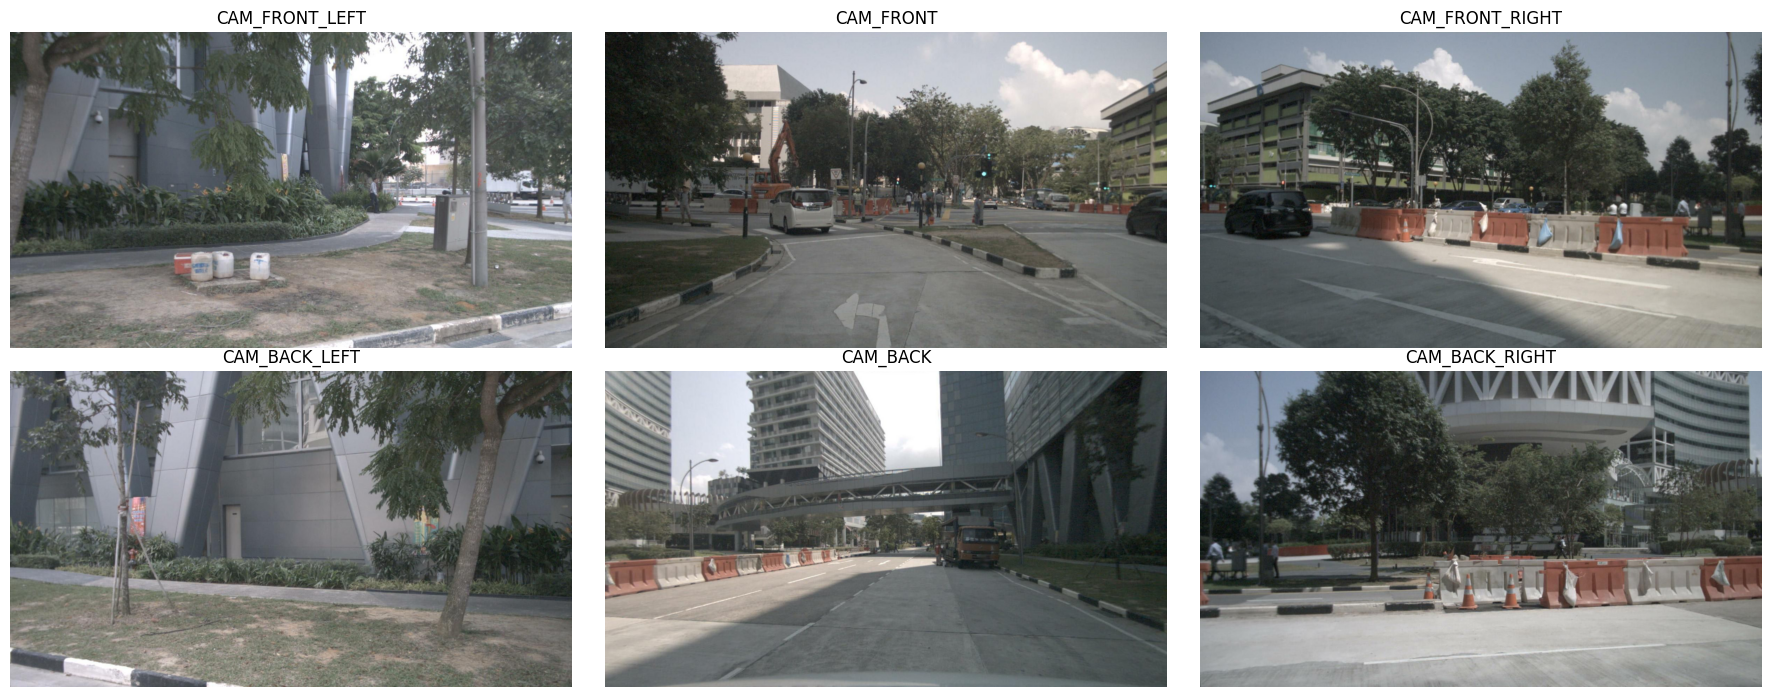

In [4]:
def read_camera_image(nusc, sample, sensor):
    sd_token = sample['data'][sensor]
    sd = nusc.get('sample_data', sd_token)
    path = Path(nusc.dataroot) / sd['filename']
    bgr = cv2.imread(str(path))
    if bgr is None:
        raise FileNotFoundError(path)
    return bgr, sd

fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for ax, sensor in zip(axes.ravel(), CAMERAS):
    img, _ = read_camera_image(nusc, sample, sensor)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(sensor)
    ax.axis('off')
plt.tight_layout()


In [5]:
# Detection confidence threshold. Increase it for fewer but cleaner boxes; decrease it for more recall.
DET_CONF = 0.35

# TorchVision COCO detector.
det_weights = SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
object_detector = ssdlite320_mobilenet_v3_large(weights=det_weights).to(DEVICE).eval()
COCO_CATEGORIES = det_weights.meta['categories']

# YOLOP: drivable area segmentation + lane line segmentation.
# ??????? GitHub/PyTorch Hub ??????????
yolop_model = torch.hub.load('hustvl/yolop', 'yolop', pretrained=True, trust_repo=True)
yolop_model = yolop_model.to(DEVICE).eval()
print('TorchVision detector and YOLOP loaded')


Using cache found in C:\Users\Minghe Liu/.cache\torch\hub\hustvl_yolop_main


TorchVision detector and YOLOP loaded


In [6]:
TARGET_DET_CLASSES = {'car', 'truck', 'bus', 'person', 'bicycle', 'motorcycle'}


def _binary_from_yolop_output(seg_out):
    """Convert YOLOP segmentation output to a binary 640x640 uint8 mask."""
    if isinstance(seg_out, (list, tuple)):
        seg_out = seg_out[0]
    seg = seg_out.detach()

    # Common YOLOP shape: [B, C, H, W]. If C=2, argmax gives background/foreground.
    if seg.ndim == 4:
        if seg.shape[1] > 1:
            mask = torch.argmax(seg, dim=1)[0]
        else:
            mask = (torch.sigmoid(seg[0, 0]) > 0.5).long()
    elif seg.ndim == 3:
        if seg.shape[0] > 1:
            mask = torch.argmax(seg, dim=0)
        else:
            mask = (torch.sigmoid(seg[0]) > 0.5).long()
    else:
        mask = (torch.sigmoid(seg) > 0.5).long()

    return (mask.detach().cpu().numpy().astype(np.uint8) * 255)


@torch.inference_mode()
def yolop_segment_masks(bgr):
    """Return drivable-area mask and lane-line mask in the original image size."""
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (640, 640), interpolation=cv2.INTER_LINEAR)
    tensor = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    tensor = tensor.unsqueeze(0).to(DEVICE)

    _, da_seg_out, ll_seg_out = yolop_model(tensor)
    da_mask = _binary_from_yolop_output(da_seg_out)
    ll_mask = _binary_from_yolop_output(ll_seg_out)

    da_mask = cv2.resize(da_mask, (w, h), interpolation=cv2.INTER_NEAREST)
    ll_mask = cv2.resize(ll_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    kernel = np.ones((3, 3), np.uint8)
    da_mask = cv2.morphologyEx(da_mask, cv2.MORPH_CLOSE, kernel)
    ll_mask = cv2.morphologyEx(ll_mask, cv2.MORPH_OPEN, kernel)
    return da_mask, ll_mask


def segment_road_mask(bgr):
    """Compatibility wrapper: return drivable area only."""
    da_mask, _ = yolop_segment_masks(bgr)
    return da_mask


def detect_objects(bgr, conf=DET_CONF):
    """Run TorchVision COCO detector and keep traffic-related classes above DET_CONF."""
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    tensor = TVF.to_tensor(rgb).to(DEVICE)
    with torch.inference_mode():
        result = object_detector([tensor])[0]

    detections = []
    boxes = result['boxes'].detach().cpu().numpy()
    labels = result['labels'].detach().cpu().numpy()
    scores = result['scores'].detach().cpu().numpy()

    for xyxy, cls_id, score in zip(boxes, labels, scores):
        if float(score) < conf:
            continue
        label = COCO_CATEGORIES[int(cls_id)]
        if label not in TARGET_DET_CLASSES:
            continue
        x1, y1, x2, y2 = xyxy.astype(float)
        detections.append({
            'label': label,
            'conf': float(score),
            'bbox': [x1, y1, x2, y2],
            'foot_pixel': [(x1 + x2) / 2.0, y2],
        })
    return detections


P:\Users\Minghe Liu\Code\Courses\washu-5509\Project\.venv311\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


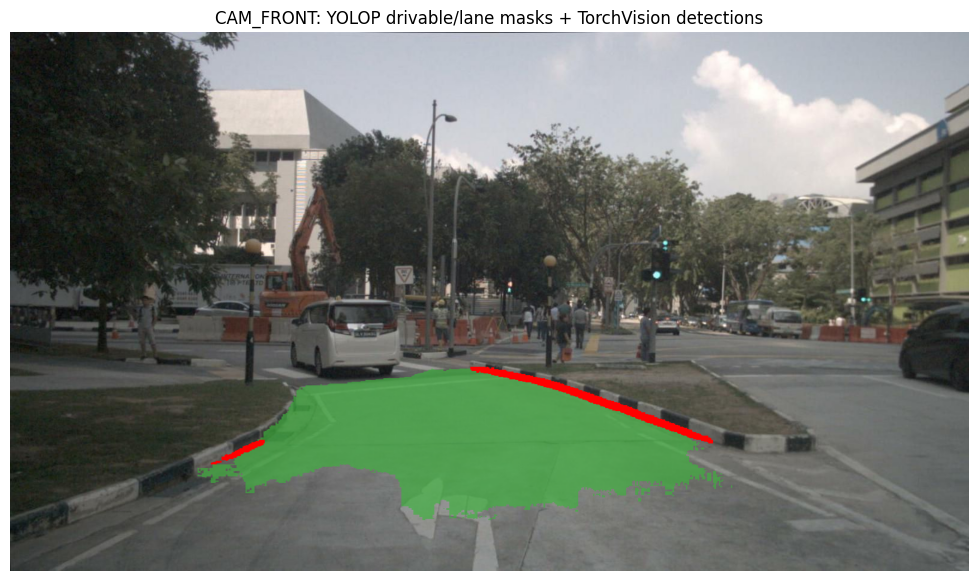

In [7]:
# Quick sanity check on CAM_FRONT
front_img, _ = read_camera_image(nusc, sample, 'CAM_FRONT')
front_mask, front_lane = yolop_segment_masks(front_img)
front_det = detect_objects(front_img)

vis = front_img.copy()
vis[front_mask > 0] = cv2.addWeighted(vis, 0.35, np.full_like(vis, (60, 180, 60)), 0.65, 0)[front_mask > 0]
vis[front_lane > 0] = (0, 0, 255)
for det in front_det:
    x1, y1, x2, y2 = map(int, det['bbox'])
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 2)
    cv2.circle(vis, tuple(map(int, det['foot_pixel'])), 5, (255, 0, 0), -1)
    cv2.putText(vis, f"{det['label']} {det['conf']:.2f}", (x1, max(20, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('CAM_FRONT: YOLOP drivable/lane masks + TorchVision detections')
plt.axis('off')
plt.show()


## 2. NuScenes ????

NuScenes ego ?????`x` ???????`y` ?????`z` ???????????????? `z = 0` ??????


In [8]:
def camera_calibration(nusc, sample, sensor):
    """Return camera intrinsic K, sensor-to-ego rotation R, translation t, and sample_data."""
    _, sd = read_camera_image(nusc, sample, sensor)
    cs = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    K = np.array(cs['camera_intrinsic'], dtype=np.float64)
    R = Quaternion(cs['rotation']).rotation_matrix.astype(np.float64)  # camera -> ego
    t = np.array(cs['translation'], dtype=np.float64)                  # camera origin in ego
    return K, R, t, sd


def pixels_to_ego_ground(pixels_uv, K, R_cam_to_ego, t_cam_to_ego):
    """Intersect camera rays with ego ground plane z=0.

    pixels_uv: array of shape [N, 2], image pixel coordinates.
    returns points_xy: [N, 2] in ego meters, valid mask.
    """
    pixels_uv = np.asarray(pixels_uv, dtype=np.float64)
    ones = np.ones((len(pixels_uv), 1), dtype=np.float64)
    pix_h = np.concatenate([pixels_uv, ones], axis=1)

    rays_cam = (np.linalg.inv(K) @ pix_h.T).T
    rays_ego = (R_cam_to_ego @ rays_cam.T).T
    origin = t_cam_to_ego.reshape(1, 3)

    denom = rays_ego[:, 2]
    scale = -origin[:, 2] / denom
    pts_ego = origin + scale[:, None] * rays_ego
    valid = (np.abs(denom) > 1e-6) & (scale > 0)
    return pts_ego[:, :2], valid


def ego_ground_to_pixels(points_xy, K, R_cam_to_ego, t_cam_to_ego):
    """Project ego ground points [x_forward, y_left] into a camera image."""
    points_xy = np.asarray(points_xy, dtype=np.float64)
    pts_ego = np.column_stack([points_xy[:, 0], points_xy[:, 1], np.zeros(len(points_xy))])
    pts_cam = (R_cam_to_ego.T @ (pts_ego - t_cam_to_ego).T).T
    z = pts_cam[:, 2]
    uvw = (K @ pts_cam.T).T
    uv = uvw[:, :2] / uvw[:, 2:3]
    valid = z > 1e-3
    return uv, valid


In [9]:
# BEV canvas configuration, in meters.
BEV_CFG = {
    'x_min': -10.0,  # behind ego
    'x_max': 55.0,   # front of ego
    'y_min': -32.5,  # right side is negative y
    'y_max': 32.5,   # left side is positive y
    'resolution': 0.10,  # meters / pixel
}

BEV_H = int((BEV_CFG['x_max'] - BEV_CFG['x_min']) / BEV_CFG['resolution'])
BEV_W = int((BEV_CFG['y_max'] - BEV_CFG['y_min']) / BEV_CFG['resolution'])
print('BEV size:', BEV_W, 'x', BEV_H)


def ego_xy_to_bev_px(xy, cfg=BEV_CFG):
    xy = np.asarray(xy, dtype=np.float64)
    x_forward = xy[:, 0]
    y_left = xy[:, 1]
    col = (cfg['y_max'] - y_left) / cfg['resolution']
    row = (cfg['x_max'] - x_forward) / cfg['resolution']
    return np.column_stack([col, row])


def bev_px_to_ego_xy(cols, rows, cfg=BEV_CFG):
    y_left = cfg['y_max'] - cols * cfg['resolution']
    x_forward = cfg['x_max'] - rows * cfg['resolution']
    return np.column_stack([x_forward.ravel(), y_left.ravel()])


BEV size: 650 x 650


In [10]:
def warp_image_or_mask_to_bev(src, nusc, sample, sensor, interpolation=cv2.INTER_LINEAR):
    """Inverse-warp a camera image/mask onto the ego ground plane BEV grid."""
    K, R, t, _ = camera_calibration(nusc, sample, sensor)
    h_img, w_img = src.shape[:2]

    rows, cols = np.indices((BEV_H, BEV_W), dtype=np.float32)
    ground_xy = bev_px_to_ego_xy(cols, rows)
    uv, in_front = ego_ground_to_pixels(ground_xy, K, R, t)
    u = uv[:, 0].reshape(BEV_H, BEV_W).astype(np.float32)
    v = uv[:, 1].reshape(BEV_H, BEV_W).astype(np.float32)
    valid = (in_front.reshape(BEV_H, BEV_W) & (u >= 0) & (u < w_img - 1) & (v >= 0) & (v < h_img - 1))

    map_x = np.where(valid, u, -1).astype(np.float32)
    map_y = np.where(valid, v, -1).astype(np.float32)
    warped = cv2.remap(src, map_x, map_y, interpolation, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return warped, valid


def detections_to_bev_points(detections, nusc, sample, sensor):
    K, R, t, _ = camera_calibration(nusc, sample, sensor)
    if not detections:
        return []
    foot_pixels = np.array([d['foot_pixel'] for d in detections], dtype=np.float64)
    pts_xy, valid = pixels_to_ego_ground(foot_pixels, K, R, t)
    bev_px = ego_xy_to_bev_px(pts_xy)

    out = []
    for det, xy, px, ok in zip(detections, pts_xy, bev_px, valid):
        col, row = px
        inside = 0 <= col < BEV_W and 0 <= row < BEV_H
        if ok and inside:
            item = dict(det)
            item.update({'sensor': sensor, 'ego_xy': xy.tolist(), 'bev_px': [float(col), float(row)]})
            out.append(item)
    return out


## 3. ?? BEV

????????? 6 ????

- ? YOLOP drivable-area mask ? lane-line mask ???????? BEV ????????????
- ?????????????????? BEV ??????
- ???????????????????????????????????????????????????????? `use_image_texture='road'` ? `use_image_texture='all'`?


In [11]:
def draw_bev_grid(canvas, cfg=BEV_CFG):
    h, w = canvas.shape[:2]
    color = (80, 80, 80)
    # distance rings in front of ego
    for dist in range(0, int(cfg['x_max']) + 1, 10):
        row = int((cfg['x_max'] - dist) / cfg['resolution'])
        if 0 <= row < h:
            cv2.line(canvas, (0, row), (w, row), color, 1)
            cv2.putText(canvas, f'{dist}m', (8, max(18, row - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (160, 160, 160), 1)
    for lateral in range(-30, 31, 10):
        col = int((cfg['y_max'] - lateral) / cfg['resolution'])
        if 0 <= col < w:
            cv2.line(canvas, (col, 0), (col, h), (55, 55, 55), 1)
    return canvas


def draw_ego_vehicle(canvas, cfg=BEV_CFG):
    # approximate ego car footprint: length 4.6m, width 2.0m, centered near x=0.
    corners_xy = np.array([
        [ 2.3,  1.0], [ 2.3, -1.0], [-2.3, -1.0], [-2.3,  1.0]
    ])
    corners_px = ego_xy_to_bev_px(corners_xy).astype(np.int32)
    cv2.fillPoly(canvas, [corners_px], (30, 220, 120))
    cv2.polylines(canvas, [corners_px], True, (230, 255, 240), 2)
    return canvas


def make_bev(nusc, sample, cameras=CAMERAS, use_image_texture=False):
    texture_acc = np.zeros((BEV_H, BEV_W, 3), dtype=np.float32)
    texture_count = np.zeros((BEV_H, BEV_W, 1), dtype=np.float32)
    road_acc = np.zeros((BEV_H, BEV_W), dtype=np.uint8)
    lane_acc = np.zeros((BEV_H, BEV_W), dtype=np.uint8)
    all_bev_dets = []

    for sensor in tqdm(cameras):
        bgr, _ = read_camera_image(nusc, sample, sensor)
        road_mask, lane_mask = yolop_segment_masks(bgr)
        detections = detect_objects(bgr)

        warped_road, _ = warp_image_or_mask_to_bev(road_mask, nusc, sample, sensor, interpolation=cv2.INTER_NEAREST)
        warped_lane, _ = warp_image_or_mask_to_bev(lane_mask, nusc, sample, sensor, interpolation=cv2.INTER_NEAREST)

        if use_image_texture:
            warped_img, valid_img = warp_image_or_mask_to_bev(bgr, nusc, sample, sensor, interpolation=cv2.INTER_LINEAR)
            # Full image texture creates strong radial stretching because buildings/vehicles are not on z=0.
            # Use use_image_texture='road' to keep texture only where the road mask projects.
            texture_mask = valid_img if use_image_texture == 'all' else (valid_img & (warped_road > 0))
            texture_acc[texture_mask] += warped_img[texture_mask].astype(np.float32)
            texture_count[texture_mask] += 1.0
        road_acc = np.maximum(road_acc, warped_road)
        lane_acc = np.maximum(lane_acc, warped_lane)
        all_bev_dets.extend(detections_to_bev_points(detections, nusc, sample, sensor))

    canvas = np.full((BEV_H, BEV_W, 3), 32, dtype=np.uint8)
    if use_image_texture:
        avg_texture = texture_acc / np.maximum(texture_count, 1.0)
        has_texture = texture_count[:, :, 0] > 0
        canvas[has_texture] = cv2.addWeighted(canvas[has_texture], 0.35, avg_texture[has_texture].astype(np.uint8), 0.65, 0)

    # Drivable area overlay: green translucent mask.
    road_pixels = road_acc > 0
    road_color = np.full_like(canvas, (45, 150, 80))
    canvas[road_pixels] = cv2.addWeighted(canvas, 0.35, road_color, 0.65, 0)[road_pixels]

    # Lane lines: red/white markers on top of the drivable area.
    lane_pixels = lane_acc > 0
    canvas[lane_pixels] = (245, 245, 245)

    draw_bev_grid(canvas)
    draw_ego_vehicle(canvas)

    colors = {
        'person': (70, 170, 255),
        'bicycle': (255, 180, 80),
        'motorcycle': (255, 180, 80),
        'car': (0, 245, 255),
        'truck': (0, 210, 255),
        'bus': (0, 210, 255),
    }
    for det in all_bev_dets:
        col, row = map(int, det['bev_px'])
        color = colors.get(det['label'], (255, 255, 255))
        cv2.circle(canvas, (col, row), 7, color, -1)
        cv2.circle(canvas, (col, row), 10, (20, 20, 20), 2)
        text = f"{det['label']} {det['conf']:.2f}"
        cv2.putText(canvas, text, (col + 10, row - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)

    return canvas, all_bev_dets, road_acc, lane_acc


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.56it/s]


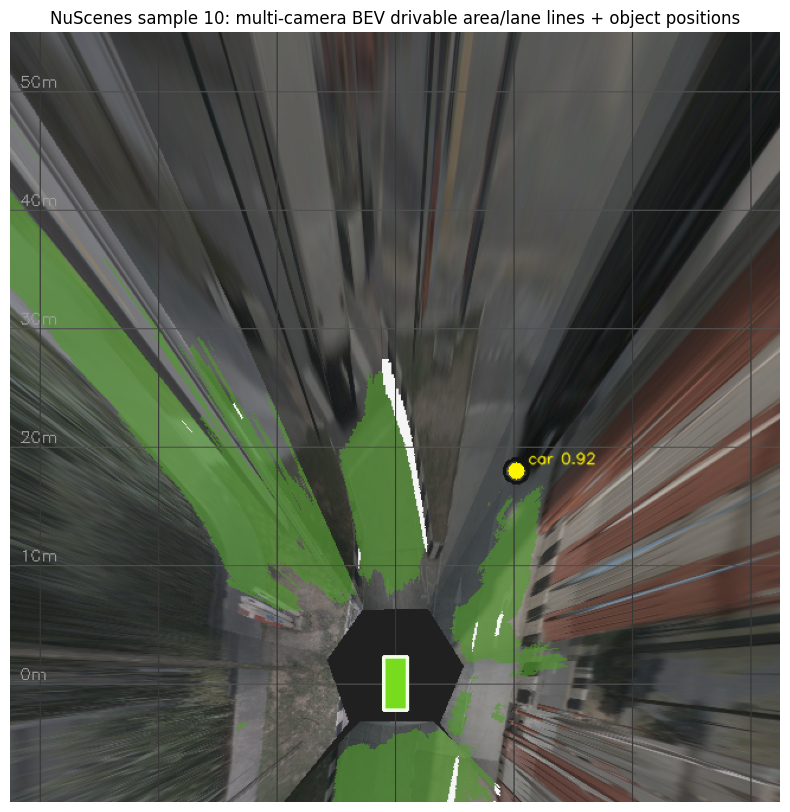

Projected detections:
CAM_FRONT_RIGHT  car        conf=0.92  ego_xy=( 17.96m forward, -10.20m left)


In [16]:
# Clean BEV: mask-only, no full-image texture stretching.
bev, bev_dets, road_bev, lane_bev = make_bev(nusc, sample, use_image_texture='all')
# For debugging geometry, try: make_bev(nusc, sample, use_image_texture='road')

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(bev, cv2.COLOR_BGR2RGB))
plt.title(f'NuScenes sample {SAMPLE_INDEX}: multi-camera BEV drivable area/lane lines + object positions')
plt.axis('off')
plt.show()

print('Projected detections:')
for d in bev_dets:
    x, y = d['ego_xy']
    print(f"{d['sensor']:<16} {d['label']:<10} conf={d['conf']:.2f}  ego_xy=({x:6.2f}m forward, {y:6.2f}m left)")


## 4. ????????


In [17]:
OUT_DIR = Path('./output')
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / f'bev_sample_{SAMPLE_INDEX}.png'
cv2.imwrite(str(out_path), bev)
print('saved to:', out_path)


saved to: output\bev_sample_10.png
